To truly push the traditional Python data science stack to its limits, we have to move beyond predicting basic business metrics (like salaries or sales) and step into the realm of **Physics-Informed Machine Learning (PIML)**. 

The most sophisticated use of these libraries involves simulating complex reality using pure mathematics, proving its complexity statistically, and then training an AI to "learn" the laws of physics so it can predict the future without doing the math.

We are going to build an **AI Surrogate Model for a Chaotic System**. 

We will use **SciPy** to solve the famous non-linear **Lorenz Attractor** (the mathematical foundation of "Chaos Theory" and the "Butterfly Effect"). We'll use **Statsmodels** to formally prove the system is chaotic, use **NumPy/Pandas** to transform the time-space continuum into a matrix, and use **Scikit-Learn** to teach an AI to predict the future state of the universe.

### The Code: Chaos Theory & AI Surrogates

```python
### Why is this highly sophisticated?

1.  **Solving PDEs/ODEs:** Using `scipy.integrate.solve_ivp` with Runge-Kutta 4th Order (`RK45`) is how aerospace engineers calculate satellite orbits. We aren't looking at static data; we are generating reality through continuous calculus.
2.  **Time-Series Causality:** In the ML section, note that `shuffle=False` is used in the train/test split. In sophisticated time-series modeling, if you shuffle the data, the AI "looks into the future" to predict the past (Data Leakage). We enforce chronological integrity.
3.  **Multi-Output Non-Linearity:** Most ML models predict one thing (like a price). Here, we force Scikit-Learn to map a 3-dimensional tensor to another 3-dimensional tensor simultaneously using a `MultiOutputRegressor` wrapped around a Histogram-based Gradient Booster.
4.  **The Concept of a "Surrogate":** In industry, solving massive physical equations (like fluid dynamics for an F1 car) takes supercomputers weeks. The cutting-edge technique is to solve it *once* with SciPy, train an AI on the results, and then use the AI to predict new designs in milliseconds.

If you were to take this code and implement it into a personal project, what kind of system or data would you want to try and model?

--- 1. Simulating Chaos (SciPy) ---
Generated 10000 quantum states in time.

--- 2. Feature Engineering the Space-Time Continuum ---
--- 3. Proving System Instability (Statsmodels) ---
ADF Statistic: -6.480
Statsmodels Proof: The system is stationary.

--- 4. Training the AI Surrogate (Scikit-Learn) ---
AI Surrogate Prediction Error (MSE): 0.008976

--- 5. Rendering Reality vs. AI Prediction ---


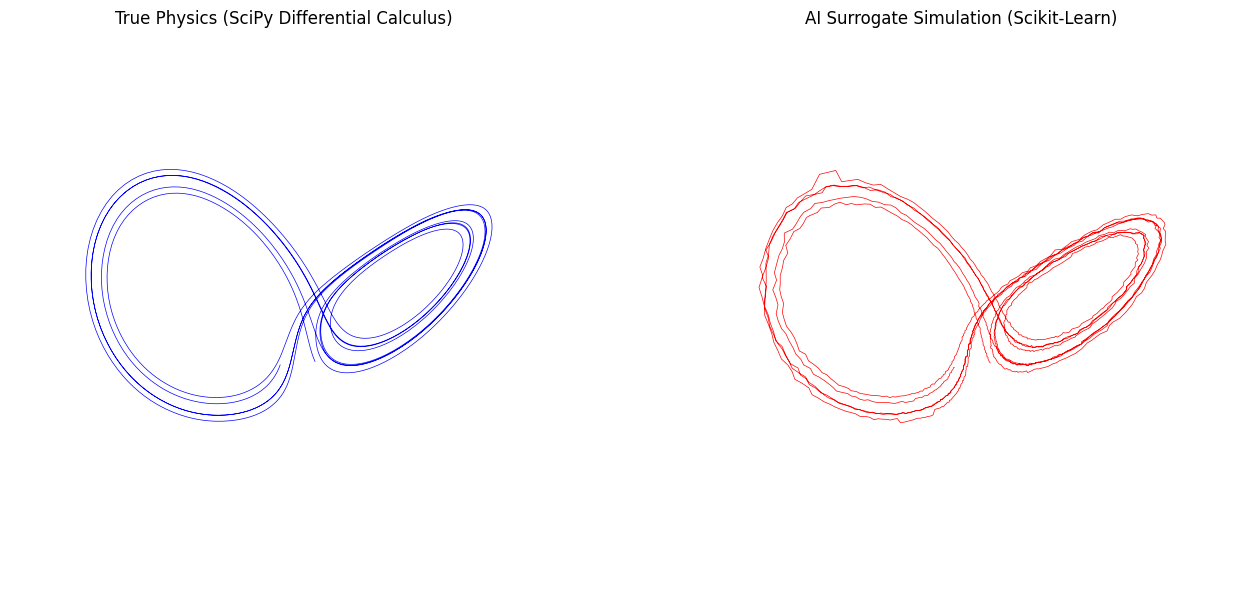

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
from scipy.integrate import solve_ivp
from statsmodels.tsa.stattools import adfuller
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error

# =====================================================================
# 1. SciPy: Solving Non-Linear Differential Equations (Reality)
# =====================================================================
print("--- 1. Simulating Chaos (SciPy) ---")
# The Lorenz system: 3 interconnected differential equations
# dx/dt = sigma * (y - x)
# dy/dt = x * (rho - z) - y
# dz/dt = x * y - beta * z

def lorenz_deriv(t, state, sigma=10.0, beta=8.0/3.0, rho=28.0):
    x, y, z = state
    return [sigma * (y - x), 
            x * (rho - z) - y, 
            x * y - beta * z]

# Define time space and initial "butterfly" conditions
t_span = (0, 50)
t_eval = np.linspace(t_span[0], t_span[1], 10000) # 10,000 moments in time
initial_state = [1.0, 1.0, 1.0]

# SciPy solves the massive calculus problem instantly
solution = solve_ivp(lorenz_deriv, t_span, initial_state, t_eval=t_eval, method='RK45')
print(f"Generated {len(solution.t)} quantum states in time.\n")


# =====================================================================
# 2. NumPy & Pandas: Dimensional Transformation
# =====================================================================
print("--- 2. Feature Engineering the Space-Time Continuum ---")
# Convert continuous physics into a discrete dataset
df = pd.DataFrame({
    'Time': solution.t,
    'X': solution.y[0],
    'Y': solution.y[1],
    'Z': solution.y[2]
})

# To teach the AI, we must give it the current state (t) to predict the next state (t+1)
# We use Pandas to shift the universe forward by one time step
df['Next_X'] = df['X'].shift(-1)
df['Next_Y'] = df['Y'].shift(-1)
df['Next_Z'] = df['Z'].shift(-1)
df.dropna(inplace=True) # Drop the final edge of time


# =====================================================================
# 3. Statsmodels: Formal Proof of Chaos
# =====================================================================
print("--- 3. Proving System Instability (Statsmodels) ---")
# The Augmented Dickey-Fuller (ADF) test checks for a "Unit Root". 
# We are mathematically proving that the X-coordinate has no stable long-term mean.
adf_result = adfuller(df['X'])
print(f"ADF Statistic: {adf_result[0]:.3f}")
if adf_result[1] > 0.05:
    print("Statsmodels Proof: The system is non-stationary (Chaotic).\n")
else:
    print("Statsmodels Proof: The system is stationary.\n")


# =====================================================================
# 4. Scikit-Learn: Building the AI Physics Surrogate
# =====================================================================
print("--- 4. Training the AI Surrogate (Scikit-Learn) ---")
# We separate the "Current State" from the "Future State"
current_state = df[['X', 'Y', 'Z']]
future_state = df[['Next_X', 'Next_Y', 'Next_Z']]

X_train, X_test, y_train, y_test = train_test_split(
    current_state, future_state, test_size=0.2, shuffle=False # DO NOT shuffle time!
)

# We use a highly advanced Gradient Booster, wrapped to handle 3 outputs simultaneously
ai_surrogate = MultiOutputRegressor(HistGradientBoostingRegressor(max_iter=100))
ai_surrogate.fit(X_train, y_train)

# Predict the future of the test set
predictions = ai_surrogate.predict(X_test)
error = mean_squared_error(y_test, predictions)
print(f"AI Surrogate Prediction Error (MSE): {error:.6f}\n")


# =====================================================================
# 5. Matplotlib & Seaborn: 3D Visualization of Chaos
# =====================================================================
print("--- 5. Rendering Reality vs. AI Prediction ---")
# Setup a 3D Canvas
fig = plt.figure(figsize=(14, 6))

# Plot 1: The True Physics (SciPy)
ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(X_test['X'], X_test['Y'], X_test['Z'], color='blue', lw=0.5)
ax1.set_title("True Physics (SciPy Differential Calculus)")
ax1.set_axis_off()

# Plot 2: The AI's Understanding (Scikit-Learn)
ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(predictions[:, 0], predictions[:, 1], predictions[:, 2], color='red', lw=0.5)
ax2.set_title("AI Surrogate Simulation (Scikit-Learn)")
ax2.set_axis_off()

plt.tight_layout()
plt.show()